# Edit TEST_IMG_DIR in Cell 2

In [2]:
!pip install transformers torch torchvision pillow tqdm gdown -q
print('✅ Done')


✅ Done


## Cell 1.5 — Download Checkpoints from Google Drive

In [3]:
import os

# -- OCR checkpoint (TrOCR) ---------------------------------------------------
# Folder: https://drive.google.com/drive/folders/1BebRTkIuFVzeFGfYiTCB3No_aSJWq44l
os.makedirs('/content/ckpts/ocr', exist_ok=True)
print('Downloading OCR checkpoint...')
!gdown --folder "https://drive.google.com/drive/folders/1BebRTkIuFVzeFGfYiTCB3No_aSJWq44l" \
       -O /content/ckpts/ocr --remaining-ok

!gdown --folder "https://drive.google.com/drive/folders/1MHCYFy8oPbOYdYvrl-BRlACP6dXhahaw?usp=drive_link" \
       -O /content/ckpts/dt --remaining-ok

TROCR_DL = '/content/ckpts/ocr'
print(f'OK OCR checkpoint -> {TROCR_DL}')


Retrieving folder contents
Processing file 1qfkDaPbU1BojAwuR43fyxl5E2unk45_e config.json
Processing file 1digcvL6dKeOU-LtO9KxaEECeH93HyGto generation_config.json
Processing file 1hudilGLZo8C7_Sj-ZbK2WdMfqiN9j5Ez model.safetensors
Processing file 1S4dD3QDEDwKj3aZS3i16MTNc4wB8cwpn processor_config.json
Processing file 1oUM5ru1yXuGQecIJOi6rkWH4s-THRUER tokenizer_config.json
Processing file 1SkDqasxV4QAGLRD8CooZPubbepsCe1ff tokenizer.json
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1qfkDaPbU1BojAwuR43fyxl5E2unk45_e
To: /content/ckpts/ocr/config.json
100% 3.12k/3.12k [00:00<00:00, 12.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1digcvL6dKeOU-LtO9KxaEECeH93HyGto
To: /content/ckpts/ocr/generation_config.json
100% 281/281 [00:00<00:00, 1.38MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1hudilGLZo8C7_Sj-ZbK2WdMfqiN9j5Ez
From (redirected): https://d

In [9]:
!gdown --folder "https://drive.google.com/drive/folders/1MZ7CkH8CewzysNfLpTe6GOec_UwKO4NV?usp=drive_link" \
       -O /content/ckpts/tsr --remaining-ok

Retrieving folder contents
Processing file 1YEfw-4b8_77JUaFOLTakHlKhLHsyH6Zw config.json
Processing file 1Ddhw9A2BbSYB7DZvCj7YD7KIV0OXVUbt model.safetensors
Processing file 1gxCt_xf5uz9MNl3Jp1eriolaRYDat9iT preprocessor_config.json
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1YEfw-4b8_77JUaFOLTakHlKhLHsyH6Zw
To: /content/ckpts/tsr/config.json
100% 76.1k/76.1k [00:00<00:00, 3.06MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1Ddhw9A2BbSYB7DZvCj7YD7KIV0OXVUbt
From (redirected): https://drive.google.com/uc?id=1Ddhw9A2BbSYB7DZvCj7YD7KIV0OXVUbt&confirm=t&uuid=663b8616-de20-4bb0-9635-6dd0c6a85a6e
To: /content/ckpts/tsr/model.safetensors
100% 115M/115M [00:02<00:00, 42.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1gxCt_xf5uz9MNl3Jp1eriolaRYDat9iT
To: /content/ckpts/tsr/preprocessor_config.json
100% 474/474 [00:00<00:00, 2.69MB/s]
Download complete

## Cell 2 — Paths  ← EDIT HERE

In [18]:
import os

# ============================================================
#  EDIT PATHS HERE
# ============================================================
TD_CHECKPOINT    = '/content/ckpts/dt'  # DETR R18, PubTables-1M
TSR_CHECKPOINT   = '/content/ckpts/tsr'  # local: config.json + model.safetensors
TROCR_CHECKPOINT = '/content/ckpts/ocr'  # downloaded in Cell 1.5




TEST_IMG_DIR     = '/content/drive/MyDrive/pahse3/Images'




OUTPUT_JSON      = 'submission.json'
# ============================================================

TD_CONF      = 0.3   # table-detection confidence
TD_PAD       = 10
TSR_CONF     = 0.3   # structure-recognition confidence
MAX_TEXT_LEN = 128

print('✅ Config ready')
print(f'  TD  : {TD_CHECKPOINT}')
print(f'  TSR : {TSR_CHECKPOINT}')
print(f'  OCR : {TROCR_CHECKPOINT}')


✅ Config ready
  TD  : /content/ckpts/dt
  TSR : /content/ckpts/tsr
  OCR : /content/ckpts/ocr


## Cell 3 — Imports

In [11]:
import os, json, glob
import torch
from PIL import Image
from tqdm.notebook import tqdm
from transformers import (
    AutoImageProcessor,
    AutoModelForObjectDetection,
    TrOCRProcessor,
    VisionEncoderDecoderModel,
    GenerationConfig,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {device}')


✅ Device: cuda


In [12]:
import gc
from safetensors.torch import load_file

# ── helper: remap original DETR keys → HuggingFace TableTransformer keys ──
def remap_detr_to_hf(raw: dict) -> dict:
    hf = {}
    embed_dim = None  # will be inferred from in_proj_weight

    for k, v in raw.items():
        # ── backbone ──────────────────────────────────────────────────────
        if k.startswith("backbone.0.body."):
            new_k = "model.backbone.conv_encoder.model." + k[len("backbone.0.body."):]
            hf[new_k] = v; continue

        # ── input projection ──────────────────────────────────────────────
        if k.startswith("input_proj."):
            hf["model.input_projection." + k[len("input_proj."):]] = v; continue

        # ── query embeddings ──────────────────────────────────────────────
        if k == "query_embed.weight":
            hf["model.query_position_embeddings.weight"] = v; continue

        # ── bbox head ─────────────────────────────────────────────────────
        if k.startswith("bbox_embed."):
            hf["bbox_predictor." + k[len("bbox_embed."):]] = v; continue

        # ── class head ────────────────────────────────────────────────────
        if k.startswith("class_embed."):
            hf["class_labels_classifier." + k[len("class_embed."):]] = v; continue

        # ── encoder norm ──────────────────────────────────────────────────
        if k.startswith("transformer.encoder.norm."):
            hf["model.encoder.layernorm." + k[len("transformer.encoder.norm."):]] = v; continue

        # ── decoder norm ──────────────────────────────────────────────────
        if k.startswith("transformer.decoder.norm."):
            hf["model.decoder.layernorm." + k[len("transformer.decoder.norm."):]] = v; continue

        # ── encoder layers ────────────────────────────────────────────────
        if k.startswith("transformer.encoder.layers."):
            rest = k[len("transformer.encoder.layers."):]   # "0.norm1.weight" etc.
            idx, _, tail = rest.partition(".")

            tail = tail.replace("norm1.", "self_attn_layer_norm.") \
                       .replace("norm2.", "final_layer_norm.") \
                       .replace("linear1.", "fc1.") \
                       .replace("linear2.", "fc2.")

            # fused in_proj → split q/k/v
            if tail in ("self_attn.in_proj_weight", "self_attn.in_proj_bias"):
                embed_dim = embed_dim or v.shape[0] // 3
                d = embed_dim
                suffix = "weight" if tail.endswith("weight") else "bias"
                hf[f"model.encoder.layers.{idx}.self_attn.q_proj.{suffix}"] = v[:d]
                hf[f"model.encoder.layers.{idx}.self_attn.k_proj.{suffix}"] = v[d:2*d]
                hf[f"model.encoder.layers.{idx}.self_attn.v_proj.{suffix}"] = v[2*d:]
                continue

            hf[f"model.encoder.layers.{idx}.{tail}"] = v; continue

        # ── decoder layers ────────────────────────────────────────────────
        if k.startswith("transformer.decoder.layers."):
            rest = k[len("transformer.decoder.layers."):]
            idx, _, tail = rest.partition(".")

            tail = tail.replace("norm1.", "self_attn_layer_norm.") \
                       .replace("norm2.", "encoder_attn_layer_norm.") \
                       .replace("norm3.", "final_layer_norm.") \
                       .replace("linear1.", "fc1.") \
                       .replace("linear2.", "fc2.")

            # self-attn fused → split
            if tail in ("self_attn.in_proj_weight", "self_attn.in_proj_bias"):
                embed_dim = embed_dim or v.shape[0] // 3
                d = embed_dim
                suffix = "weight" if tail.endswith("weight") else "bias"
                hf[f"model.decoder.layers.{idx}.self_attn.q_proj.{suffix}"] = v[:d]
                hf[f"model.decoder.layers.{idx}.self_attn.k_proj.{suffix}"] = v[d:2*d]
                hf[f"model.decoder.layers.{idx}.self_attn.v_proj.{suffix}"] = v[2*d:]
                continue

            # cross-attn (multihead_attn) fused → split
            if tail in ("multihead_attn.in_proj_weight", "multihead_attn.in_proj_bias"):
                embed_dim = embed_dim or v.shape[0] // 3
                d = embed_dim
                suffix = "weight" if tail.endswith("weight") else "bias"
                hf[f"model.decoder.layers.{idx}.encoder_attn.q_proj.{suffix}"] = v[:d]
                hf[f"model.decoder.layers.{idx}.encoder_attn.k_proj.{suffix}"] = v[d:2*d]
                hf[f"model.decoder.layers.{idx}.encoder_attn.v_proj.{suffix}"] = v[2*d:]
                continue

            # cross-attn out_proj rename
            tail = tail.replace("multihead_attn.", "encoder_attn.")
            hf[f"model.decoder.layers.{idx}.{tail}"] = v; continue

        # ── anything else: pass through ───────────────────────────────────
        hf[k] = v

    return hf


# ── Load TD model ──────────────────────────────────────────────────────────
print('Loading TD...')
td_proc = AutoImageProcessor.from_pretrained(TD_CHECKPOINT)

raw_sd = load_file(f"{TD_CHECKPOINT}/model.safetensors")
hf_sd  = remap_detr_to_hf(raw_sd)

td_model = AutoModelForObjectDetection.from_pretrained(
    TD_CHECKPOINT, ignore_mismatched_sizes=True
)
missing, unexpected = td_model.load_state_dict(hf_sd, strict=False)
print(f"  Missing after remap  : {len(missing)}")
print(f"  Unexpected after remap: {len(unexpected)}")
td_model = td_model.to(device).eval()
print(f'  ✅ {td_model.config.id2label}')

Loading TD...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2586: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, whi

Loading weights: 0it [00:00, ?it/s]

TableTransformerForObjectDetection LOAD REPORT from: /content/ckpts/dt
Key                                                                          | Status     | 
-----------------------------------------------------------------------------+------------+-
transformer.decoder.layers.{0, 1, 2, 3, 4, 5}.self_attn.in_proj_bias         | UNEXPECTED | 
transformer.encoder.layers.{0, 1, 2, 3, 4, 5}.self_attn.in_proj_bias         | UNEXPECTED | 
transformer.decoder.layers.{0, 1, 2, 3, 4, 5}.norm3.weight                   | UNEXPECTED | 
transformer.decoder.layers.{0, 1, 2, 3, 4, 5}.linear2.weight                 | UNEXPECTED | 
transformer.encoder.layers.{0, 1, 2, 3, 4, 5}.norm1.weight                   | UNEXPECTED | 
transformer.decoder.layers.{0, 1, 2, 3, 4, 5}.multihead_attn.out_proj.bias   | UNEXPECTED | 
backbone.0.body.layer1.{0, 1}.bn1.running_var                                | UNEXPECTED | 
transformer.encoder.layers.{0, 1, 2, 3, 4, 5}.self_attn.in_proj_weight       | UNEXPECTED | 

  Missing after remap  : 0
  Unexpected after remap: 0
  ✅ {0: 'table', 1: 'table rotated'}


## Cell 4 — Load Models

In [13]:
import gc



# ── 2. TSR ────────────────────────────────────────────────────────────────────
from safetensors.torch import load_file

print('Loading TSR...')
tsr_proc  = AutoImageProcessor.from_pretrained(TSR_CHECKPOINT)
tsr_proc.size = {'shortest_edge': 800, 'longest_edge': 1000}

# Fix: manually load weights instead of relying on ignore_mismatched_sizes
tsr_model = AutoModelForObjectDetection.from_pretrained(
    TSR_CHECKPOINT, ignore_mismatched_sizes=True
)
# Load the actual weights directly — bypasses the config mismatch problem
tsr_sd = load_file(f"{TSR_CHECKPOINT}/model.safetensors")
missing, unexpected = tsr_model.load_state_dict(tsr_sd, strict=False)
print(f"  TSR Missing  : {len(missing)}")
print(f"  TSR Unexpected: {len(unexpected)}")

# Now set the correct labels
tsr_model.config.id2label = {
    0: 'table', 1: 'table column', 2: 'table row',
    3: 'table column header', 4: 'table projected row header',
    5: 'table spanning cell', 6: 'no object',
}
tsr_model.config.label2id = {v: k for k, v in tsr_model.config.id2label.items()}
tsr_model = tsr_model.to(device).eval()
print(f'  ✅ TSR ready  labels={tsr_model.config.id2label}')

# Sanity check — if all missing keys are in class_labels_classifier, head was re-init'd
head_missing = [k for k in missing if 'class_labels' in k]
if head_missing:
    print(f"⚠️  WARNING: Classification head was NOT loaded from checkpoint: {head_missing}")
else:
    print("✅ Classification head loaded correctly from checkpoint")


# ── 3. TrOCR — Cell Text Recognition ─────────────────────────────────────────
print('Loading TrOCR...')
best_proc  = TrOCRProcessor.from_pretrained(TROCR_CHECKPOINT)
best_model = VisionEncoderDecoderModel.from_pretrained(TROCR_CHECKPOINT).to(device).eval()
GEN_CFG = GenerationConfig(
    max_new_tokens=MAX_TEXT_LEN, num_beams=1,
    no_repeat_ngram_size=3,
)
print(f'  ✅ TrOCR ready')

gc.collect(); torch.cuda.empty_cache()
print(f'\n✅ All models loaded and ready on {device}')


Loading TSR...


Loading weights:   0%|          | 0/367 [00:00<?, ?it/s]

  TSR Missing  : 0
  TSR Unexpected: 0
  ✅ TSR ready  labels={0: 'table', 1: 'table column', 2: 'table row', 3: 'table column header', 4: 'table projected row header', 5: 'table spanning cell', 6: 'no object'}
✅ Classification head loaded correctly from checkpoint
Loading TrOCR...


Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

  ✅ TrOCR ready

✅ All models loaded and ready on cuda


## Cell 5 — Pipeline Functions

In [19]:
# -- Cell 5 -- Pipeline Functions (batched TSR + 3-round OCR per image) ------

@torch.no_grad()
def run_td(page):
    W, H = page.size
    inp  = td_proc(images=page, return_tensors='pt').to(device)
    out  = td_model(**inp)
    res  = td_proc.post_process_object_detection(
        out, threshold=TD_CONF,
        target_sizes=torch.tensor([[H, W]], device=device)
    )[0]
    return sorted([b.tolist() for b in res['boxes']], key=lambda b: b[1])


# -- Geometry helpers ----------------------------------------------------------
def box_area(b):
    return max(0, b[2]-b[0]) * max(0, b[3]-b[1])

def intersection_area(a, b):
    ix1=max(a[0],b[0]); iy1=max(a[1],b[1])
    ix2=min(a[2],b[2]); iy2=min(a[3],b[3])
    return max(0, ix2-ix1) * max(0, iy2-iy1)

def coverage(span_box, cell_box):
    ca = box_area(cell_box)
    return 0.0 if ca == 0 else intersection_area(span_box, cell_box) / ca


# -- NMS helpers ---------------------------------------------------------------
Y_NMS_IOU = 0.1
X_NMS_IOU = 0.15

def y_iou(b1, b2):
    inter = max(0, min(b1[3],b2[3]) - max(b1[1],b2[1]))
    union = max(b1[3],b2[3]) - min(b1[1],b2[1])
    return inter/union if union > 0 else 0.0

def y_nms(rows, iou_thresh=Y_NMS_IOU):
    rows = sorted(rows, key=lambda r: r['score'], reverse=True)
    kept = []
    for row in rows:
        if all(y_iou(row['box'], k['box']) < iou_thresh for k in kept):
            kept.append(row)
    return sorted(kept, key=lambda r: r['box'][1])

def x_iou(b1, b2):
    inter = max(0, min(b1[2],b2[2]) - max(b1[0],b2[0]))
    union = max(b1[2],b2[2]) - min(b1[0],b2[0])
    return inter/union if union > 0 else 0.0

def x_nms(cols, iou_thresh=X_NMS_IOU):
    cols = sorted(cols, key=lambda c: c['score'], reverse=True)
    kept = []
    for col in cols:
        if all(x_iou(col['box'], k['box']) < iou_thresh for k in kept):
            kept.append(col)
    return sorted(kept, key=lambda c: c['box'][0])


# -- TSR: single forward pass over ALL table crops ----------------------------
SPAN_CONF_MIN = 0.50
SPAN_COVER    = 0.80

@torch.no_grad()
def run_tsr_batch(crops):
    if not crops: return []
    sizes = [(c.size[1], c.size[0]) for c in crops]   # (H, W)
    inp   = tsr_proc(images=crops, return_tensors='pt').to(device)
    out   = tsr_model(**inp)
    target_sizes = torch.tensor(sizes, device=device)
    results = tsr_proc.post_process_object_detection(
        out, threshold=0.05, target_sizes=target_sizes)
    all_out = []
    for res in results:
        raw_rows, raw_cols, raw_spans = [], [], []
        for sc, lb, bx in zip(res['scores'], res['labels'], res['boxes']):
            name  = tsr_model.config.id2label.get(lb.item(), '')
            score = sc.item(); b = bx.tolist()
            if   name == 'table row'           and score > 0.30:
                raw_rows.append({'box': b, 'score': score})
            elif name == 'table column'        and score > 0.30:
                raw_cols.append({'box': b, 'score': score})
            elif name == 'table spanning cell' and score >= SPAN_CONF_MIN:
                raw_spans.append({'box': b, 'score': score})
        all_out.append((
            [r['box'] for r in y_nms(raw_rows)],
            [c['box'] for c in x_nms(raw_cols)],
            raw_spans,
        ))
    return all_out


# -- OCR ----------------------------------------------------------------------
OCR_BATCH = 32

@torch.no_grad()
def predict_text_batch(crops):
    if not crops: return []
    results   = [''] * len(crops)
    valid_idx = [i for i, c in enumerate(crops) if c.width >= 5 and c.height >= 5]
    if not valid_idx: return results
    valid_crops = [crops[i] for i in valid_idx]
    texts = []
    for i in range(0, len(valid_crops), OCR_BATCH):
        batch = valid_crops[i:i+OCR_BATCH]
        pv    = best_proc(images=batch, return_tensors='pt').pixel_values.to(device)
        ids   = best_model.generate(pv, generation_config=GEN_CFG)
        texts += best_proc.batch_decode(ids, skip_special_tokens=True)
    for idx, text in zip(valid_idx, texts):
        results[idx] = text.strip()
    return results

def safe_crop(page, bbox, W, H):
    x1,y1,x2,y2 = [int(v) for v in bbox]
    x1=max(0,x1); y1=max(0,y1); x2=min(W,x2); y2=min(H,y2)
    if x2<=x1 or y2<=y1: return None
    return page.crop((x1,y1,x2,y2))

def _blank():
    return Image.new('RGB', (32, 32), (255, 255, 255))


# -- Span geometry (no OCR inside) --------------------------------------------
def _find_span_candidates(raw_spans, base_cells):
    cands = []
    for sp in raw_spans:
        claimed = [c for c in base_cells if coverage(sp['box'], c['box']) >= SPAN_COVER]
        if len(claimed) < 2: continue
        by_row = {}
        for c in claimed: by_row.setdefault(c['ri'], []).append(c)
        for ri, rc in by_row.items():
            if len(rc) < 2: continue
            rc.sort(key=lambda c: c['ci'])
            cands.append({'score': sp['score'], 'claimed': rc,
                          'cell_keys': frozenset((c['ri'],c['ci']) for c in rc), 'row': ri})
    cands.sort(key=lambda s: s['score'], reverse=True)
    seen, unique = set(), []
    for sp in cands:
        if sp['cell_keys'] & seen: continue
        unique.append(sp); seen |= sp['cell_keys']
    return unique

def _confirm_spans(candidates, cand_cell_texts):
    confirmed = []
    for ci, sp in enumerate(candidates):
        ct = cand_cell_texts.get(ci, {})
        cs = sorted(sp['claimed'], key=lambda c: c['ci'])
        li = sp['claimed'].index(cs[0])
        lt = ct.get(li, '').strip()
        ot = [ct.get(sp['claimed'].index(c), '').strip() for c in cs[1:]]
        if lt and all(t == '' for t in ot): continue
        tc = [sp['claimed'][j] for j, t in ct.items() if t.strip()]
        if len(tc) < 2: continue
        tc.sort(key=lambda c: c['ci'])
        confirmed.append({'score': sp['score'], 'claimed': tc,
                          'cell_keys': frozenset((c['ri'],c['ci']) for c in tc), 'row': sp['row']})
    return confirmed

def _find_vspan_candidates(cell_lookup, cell_texts, n_rows, n_cols, ox, oy):
    cands, col_occ = [], set()
    for ci in range(n_cols):
        if ci != 0: continue
        ri = 0
        while ri < n_rows:
            if (ri, ci) in col_occ: ri += 1; continue
            cell = cell_lookup.get((ri, ci))
            if cell is None: ri += 1; continue
            text = cell_texts.get((ri, ci), '').strip()
            if ri > 0 and text:
                group = [cell]; look = ri + 1
                while look < n_rows:
                    below = cell_lookup.get((look, ci))
                    if below is None: break
                    if cell_texts.get((look, ci), '').strip(): break
                    group.append(below); look += 1
                if len(group) >= 2:
                    ck  = frozenset((c['ri'],c['ci']) for c in group)
                    ex1 = min(c['box'][0] for c in group)
                    ey1 = min(c['box'][1] for c in group)
                    ex2 = max(c['box'][2] for c in group)
                    ey2 = max(c['box'][3] for c in group)
                    cands.append({'cell_keys': ck, 'rowspan': len(group),
                                  'page_box': [ex1+ox, ey1+oy, ex2+ox, ey2+oy]})
                    for gc in group: col_occ.add((gc['ri'], gc['ci']))
                    ri = look; continue
            ri += 1
    return cands


# -- Main pipeline: 1 TSR call + 3 OCR calls per IMAGE (not per table) --------
def run_pipeline_submission(page_path):
    page = Image.open(page_path).convert('RGB')
    W, H = page.size

    td_boxes = run_td(page)
    if not td_boxes: return []

    # Crop all tables + run TSR once for all
    pad_boxes, table_crops = [], []
    for tx1, ty1, tx2, ty2 in td_boxes:
        cx1=max(0,tx1-TD_PAD); cy1=max(0,ty1-TD_PAD)
        cx2=min(W,tx2+TD_PAD); cy2=min(H,ty2+TD_PAD)
        pad_boxes.append((cx1,cy1,cx2,cy2))
        table_crops.append(page.crop((cx1,cy1,cx2,cy2)))

    tsr_results = run_tsr_batch(table_crops)

    # Build cell grids
    tables = []
    for t_idx, ((tx1,ty1,tx2,ty2),(cx1,cy1,cx2,cy2),crop,(rows,cols,raw_spans)) in \
            enumerate(zip(td_boxes, pad_boxes, table_crops, tsr_results)):
        if not rows or not cols: continue
        cW, cH = crop.size
        nr, nc  = len(rows), len(cols)
        cells   = []
        for ri, row in enumerate(rows):
            for ci, col in enumerate(cols):
                ix1=max(row[0],col[0]); iy1=max(row[1],col[1])
                ix2=min(row[2],col[2]); iy2=min(row[3],col[3])
                if ix2<=ix1 or iy2<=iy1: continue
                if ci==nc-1: ix2=min(cW,ix2+10)
                cells.append({'ri':ri,'ci':ci,'box':[ix1,iy1,ix2,iy2]})
        tables.append({
            't_idx': t_idx, 'td_box': (tx1,ty1,tx2,ty2),
            'ox': cx1, 'oy': cy1, 'nr': nr, 'nc': nc,
            'cells': cells, 'lookup': {(c['ri'],c['ci']):c for c in cells},
            'raw_spans': raw_spans,
        })

    if not tables: return []

    # === OCR ROUND 1: span-candidate individual cells (all tables at once) ====
    r1_crops, r1_meta, table_cands = [], [], []
    for ti, td in enumerate(tables):
        cands = _find_span_candidates(td['raw_spans'], td['cells'])
        table_cands.append(cands)
        for si, sp in enumerate(cands):
            for cj, cell in enumerate(sp['claimed']):
                pb  = [cell['box'][0]+td['ox'], cell['box'][1]+td['oy'],
                       cell['box'][2]+td['ox'], cell['box'][3]+td['oy']]
                img = safe_crop(page, pb, W, H)
                r1_crops.append(img if img else _blank())
                r1_meta.append((ti, si, cj, img is not None))

    r1_texts = predict_text_batch(r1_crops)   # single GPU call

    cand_ctexts = [{} for _ in tables]
    for (ti,si,cj,valid), text in zip(r1_meta, r1_texts):
        cand_ctexts[ti].setdefault(si,{})[cj] = text if valid else ''

    # === OCR ROUND 2: merged span boxes + all regular cells (all tables) ======
    r2_crops, r2_meta, table_confirmed = [], [], []
    for ti, td in enumerate(tables):
        confirmed = _confirm_spans(table_cands[ti], cand_ctexts[ti])
        table_confirmed.append(confirmed)
        col_occ = set()
        for sp in confirmed: col_occ |= sp['cell_keys']
        td['col_occ'] = col_occ

        for si, sp in enumerate(confirmed):       # merged span crops
            ex1=min(c['box'][0] for c in sp['claimed'])
            ey1=min(c['box'][1] for c in sp['claimed'])
            ex2=max(c['box'][2] for c in sp['claimed'])
            ey2=max(c['box'][3] for c in sp['claimed'])
            pb  = [ex1+td['ox'], ey1+td['oy'], ex2+td['ox'], ey2+td['oy']]
            img = safe_crop(page, pb, W, H)
            r2_crops.append(img if img else _blank())
            r2_meta.append(('span', ti, si))

        for cell in td['cells']:                  # regular cell crops
            if (cell['ri'],cell['ci']) in col_occ: continue
            pb  = [cell['box'][0]+td['ox'], cell['box'][1]+td['oy'],
                   cell['box'][2]+td['ox'], cell['box'][3]+td['oy']]
            img = safe_crop(page, pb, W, H)
            r2_crops.append(img if img else _blank())
            r2_meta.append(('cell', ti, cell['ri'], cell['ci']))

    r2_texts = predict_text_batch(r2_crops)   # single GPU call

    span_texts = [{} for _ in tables]
    cell_texts = [{} for _ in tables]
    for meta, text in zip(r2_meta, r2_texts):
        if meta[0]=='span': span_texts[meta[1]][meta[2]] = text
        else:               cell_texts[meta[1]][(meta[2],meta[3])] = text

    # === OCR ROUND 3: row-span merged boxes (all tables) =====================
    r3_crops, r3_meta, table_vcands = [], [], []
    for ti, td in enumerate(tables):
        vcands = _find_vspan_candidates(
            td['lookup'], cell_texts[ti], td['nr'], td['nc'], td['ox'], td['oy'])
        table_vcands.append(vcands)
        for vi, vs in enumerate(vcands):
            img = safe_crop(page, vs['page_box'], W, H)
            r3_crops.append(img if img else _blank())
            r3_meta.append((ti, vi))

    r3_texts = predict_text_batch(r3_crops)   # single GPU call

    vspan_texts = [{} for _ in tables]
    for (ti,vi), text in zip(r3_meta, r3_texts):
        vspan_texts[ti][vi] = text

    # === Assemble output =====================================================
    tables_out = []
    for ti, td in enumerate(tables):
        tx1,ty1,tx2,ty2 = td['td_box']
        col_occ = td['col_occ']
        row_occ = set()
        for vs in table_vcands[ti]: row_occ |= vs['cell_keys']
        all_occ = col_occ | row_occ

        out_cells = []

        for cell in td['cells']:                  # normal cells
            pos = (cell['ri'],cell['ci'])
            if pos in all_occ: continue
            pb = [cell['box'][0]+td['ox'], cell['box'][1]+td['oy'],
                  cell['box'][2]+td['ox'], cell['box'][3]+td['oy']]
            out_cells.append({'bbox':[int(v) for v in pb],
                'row':cell['ri'],'col':cell['ci'],'rowspan':1,'colspan':1,
                'text':cell_texts[ti].get(pos,'')})

        for si, sp in enumerate(table_confirmed[ti]):  # col-span cells
            sp2 = sorted(sp['cell_keys'])
            ex1=min(c['box'][0] for c in sp['claimed'])
            ey1=min(c['box'][1] for c in sp['claimed'])
            ex2=max(c['box'][2] for c in sp['claimed'])
            ey2=max(c['box'][3] for c in sp['claimed'])
            pb = [ex1+td['ox'],ey1+td['oy'],ex2+td['ox'],ey2+td['oy']]
            out_cells.append({'bbox':[int(v) for v in pb],
                'row':min(r for r,c in sp2),'col':min(c for r,c in sp2),
                'rowspan':1,'colspan':len(sorted(set(c for r,c in sp2))),
                'text':span_texts[ti].get(si,'')})

        for vi, vs in enumerate(table_vcands[ti]):  # row-span cells
            sp2 = sorted(vs['cell_keys'])
            out_cells.append({'bbox':[int(v) for v in vs['page_box']],
                'row':min(r for r,c in sp2),'col':min(c for r,c in sp2),
                'rowspan':vs['rowspan'],'colspan':1,
                'text':vspan_texts[ti].get(vi,'')})

        out_cells.sort(key=lambda c: (c['row'],c['col']))
        tables_out.append({'table_id':td['t_idx'],
            'bbox':[int(tx1),int(ty1),int(tx2),int(ty2)],'cells':out_cells})

    return tables_out


print('OK Pipeline ready: batched TSR + 3 OCR calls per image + greedy decoding')


OK Pipeline ready: batched TSR + 3 OCR calls per image + greedy decoding


## Cell 6 — Run Pipeline → submission.json

In [20]:
IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.tif', '.tiff')
test_paths = sorted([
    p for p in glob.glob(os.path.join(TEST_IMG_DIR, '**', '*'), recursive=True)
    if p.lower().endswith(IMG_EXTENSIONS)
])
print(f'Found {len(test_paths)} test images in {TEST_IMG_DIR}')

submission = []
errors     = []
for path in tqdm(test_paths, desc='Processing images'):


    fname = os.path.basename(path)
    try:
        tables = run_pipeline_submission(path)
        submission.append({'filename': fname, 'tables': tables})
    except Exception as e:
        errors.append((fname, str(e)))
        submission.append({'filename': fname, 'tables': []})

with open(OUTPUT_JSON, 'w') as f:
    json.dump(submission, f, indent=2, ensure_ascii=False)

total_tables = sum(len(r['tables']) for r in submission)
total_cells  = sum(len(t['cells']) for r in submission for t in r['tables'])

print(f'\n✅ Submission saved → {OUTPUT_JSON}')
print(f'   Images processed : {len(submission)}')
print(f'   Tables detected  : {total_tables}')
print(f'   Cells extracted  : {total_cells}')
if errors:
    print(f'   ⚠️  Errors        : {len(errors)}')
    for fname, err in errors[:5]:
        print(f'      {fname}: {err}')

print(f'\nPreview (first image):')
print(json.dumps(submission[0], indent=2)[:600], '...')


Found 423 test images in /content/drive/MyDrive/pahse3/Images


Processing images:   0%|          | 0/423 [00:00<?, ?it/s]


✅ Submission saved → submission.json
   Images processed : 5
   Tables detected  : 10
   Cells extracted  : 412

Preview (first image):
{
  "filename": "000001.jpg",
  "tables": [
    {
      "table_id": 0,
      "bbox": [
        128,
        556,
        1179,
        737
      ],
      "cells": [
        {
          "bbox": [
            128,
            551,
            407,
            577
          ],
          "row": 0,
          "col": 0,
          "rowspan": 1,
          "colspan": 1,
          "text": "ACOUUTUGUTTAATVC"
        },
        {
          "bbox": [
            407,
            551,
            668,
            577
          ],
          "row": 0,
          "col": 1,
          "rowspan": 1,
          "cols ...


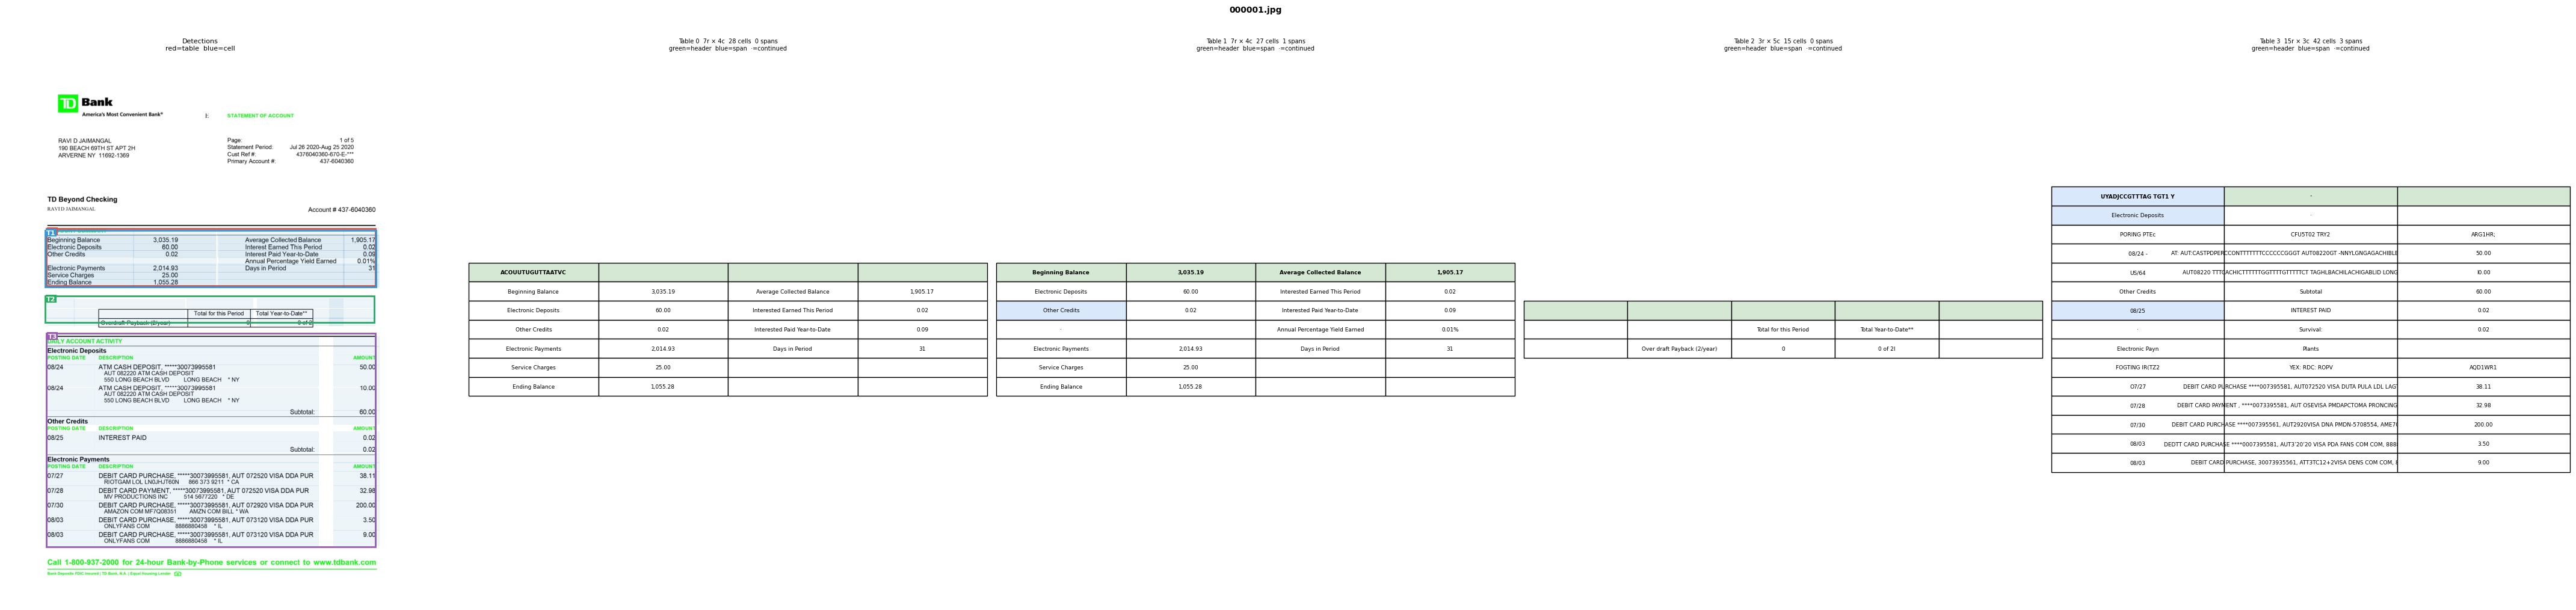

✅ 000001.jpg — 4 table(s)  saved → viz_000001.png


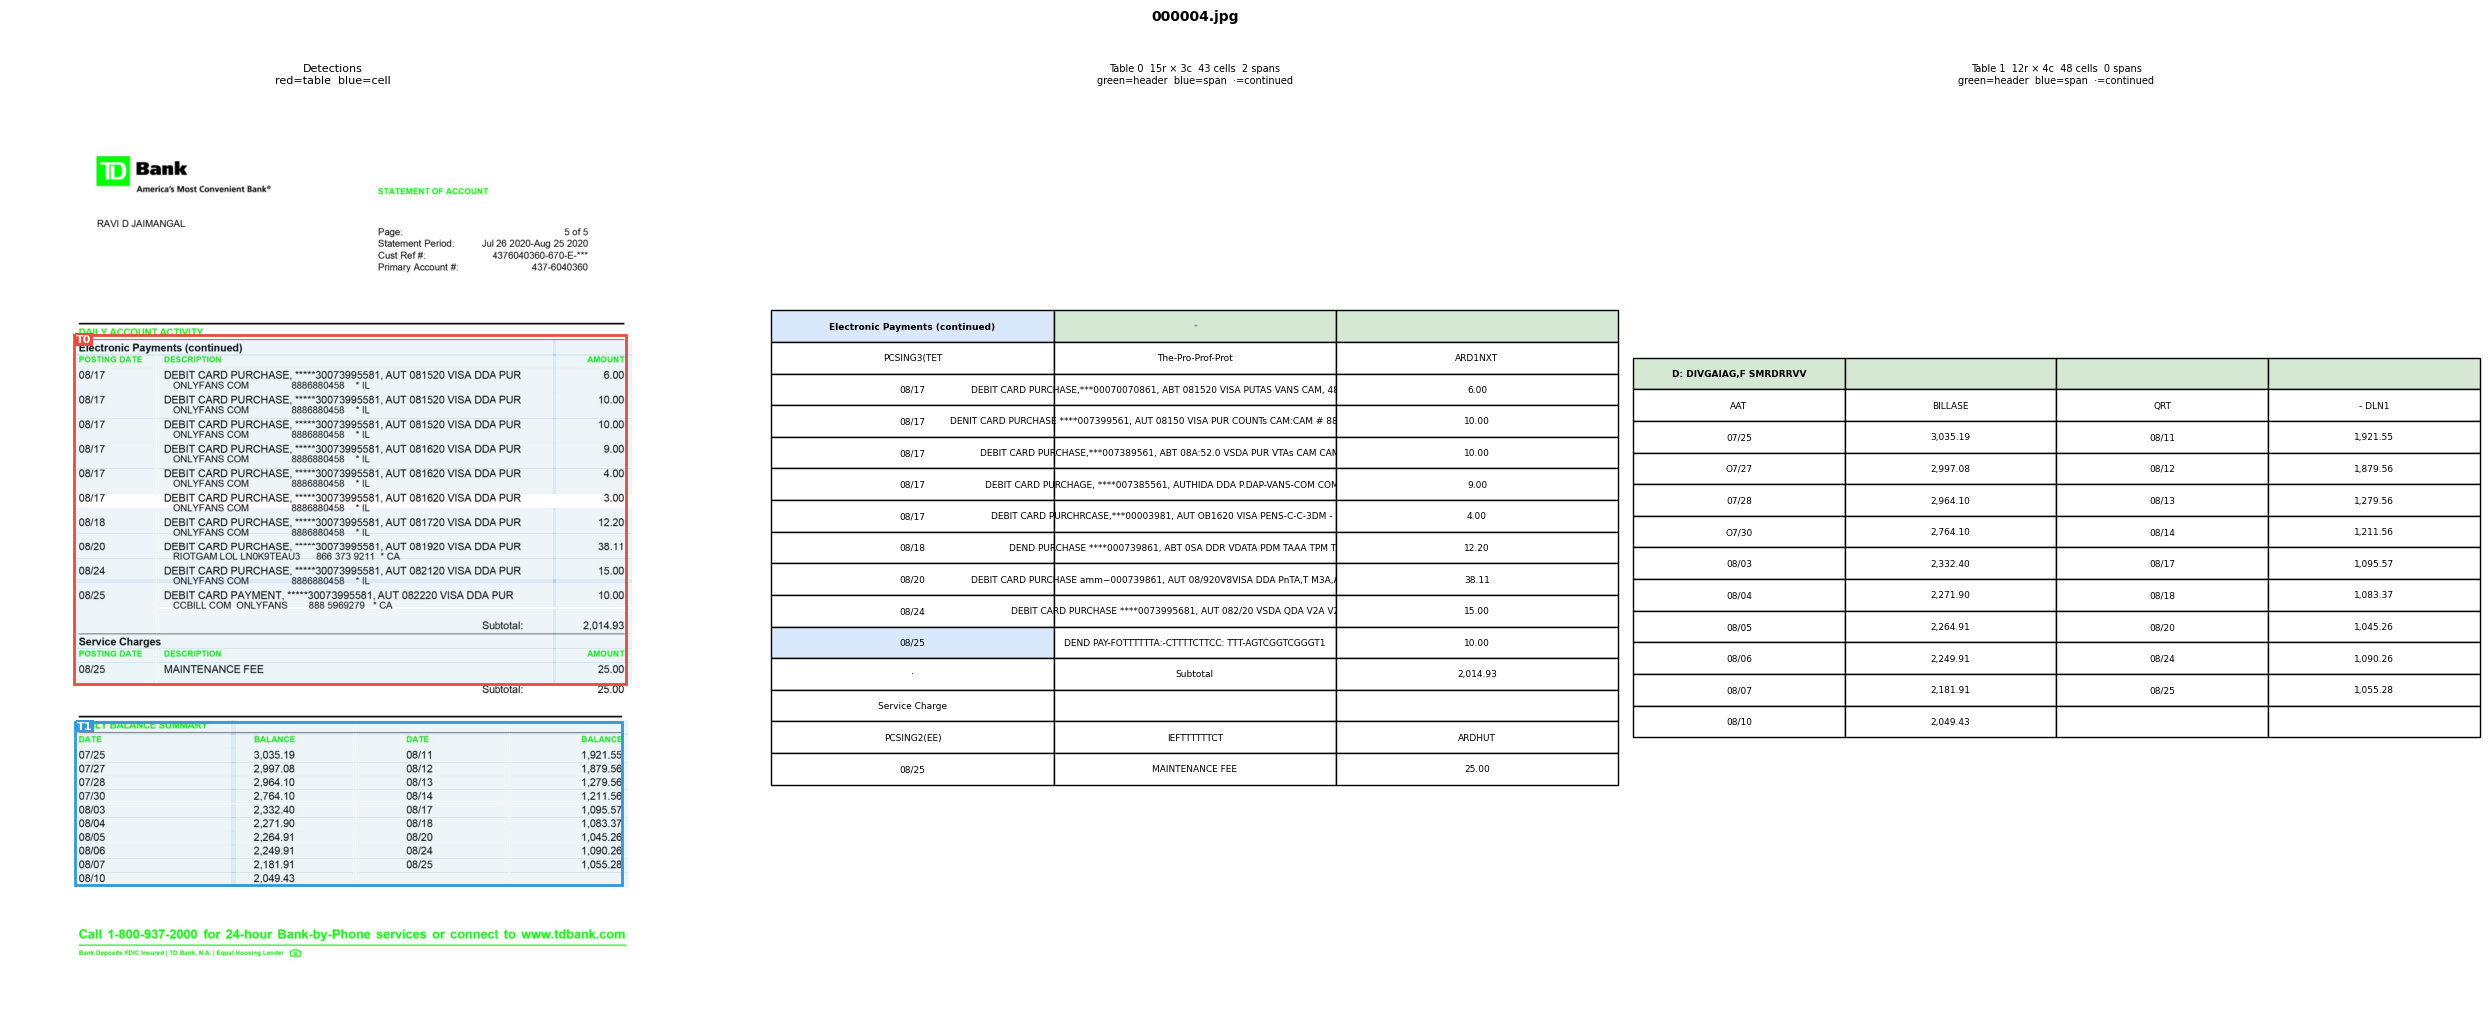

✅ 000004.jpg — 2 table(s)  saved → viz_000004.png


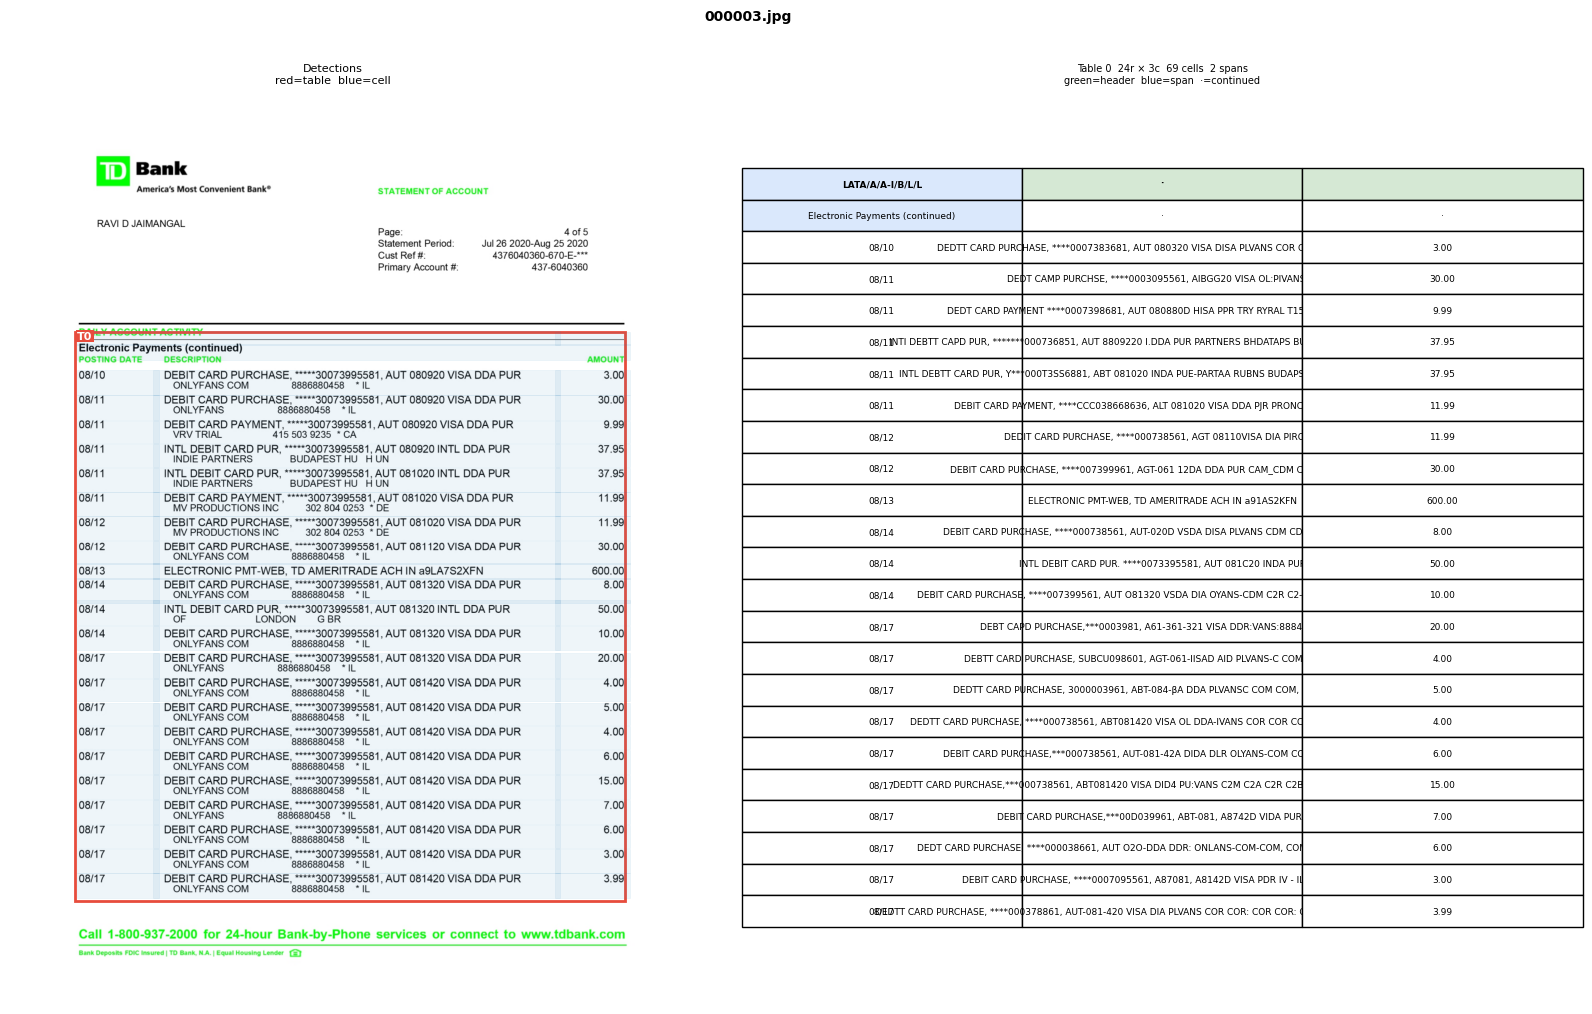

✅ 000003.jpg — 1 table(s)  saved → viz_000003.png


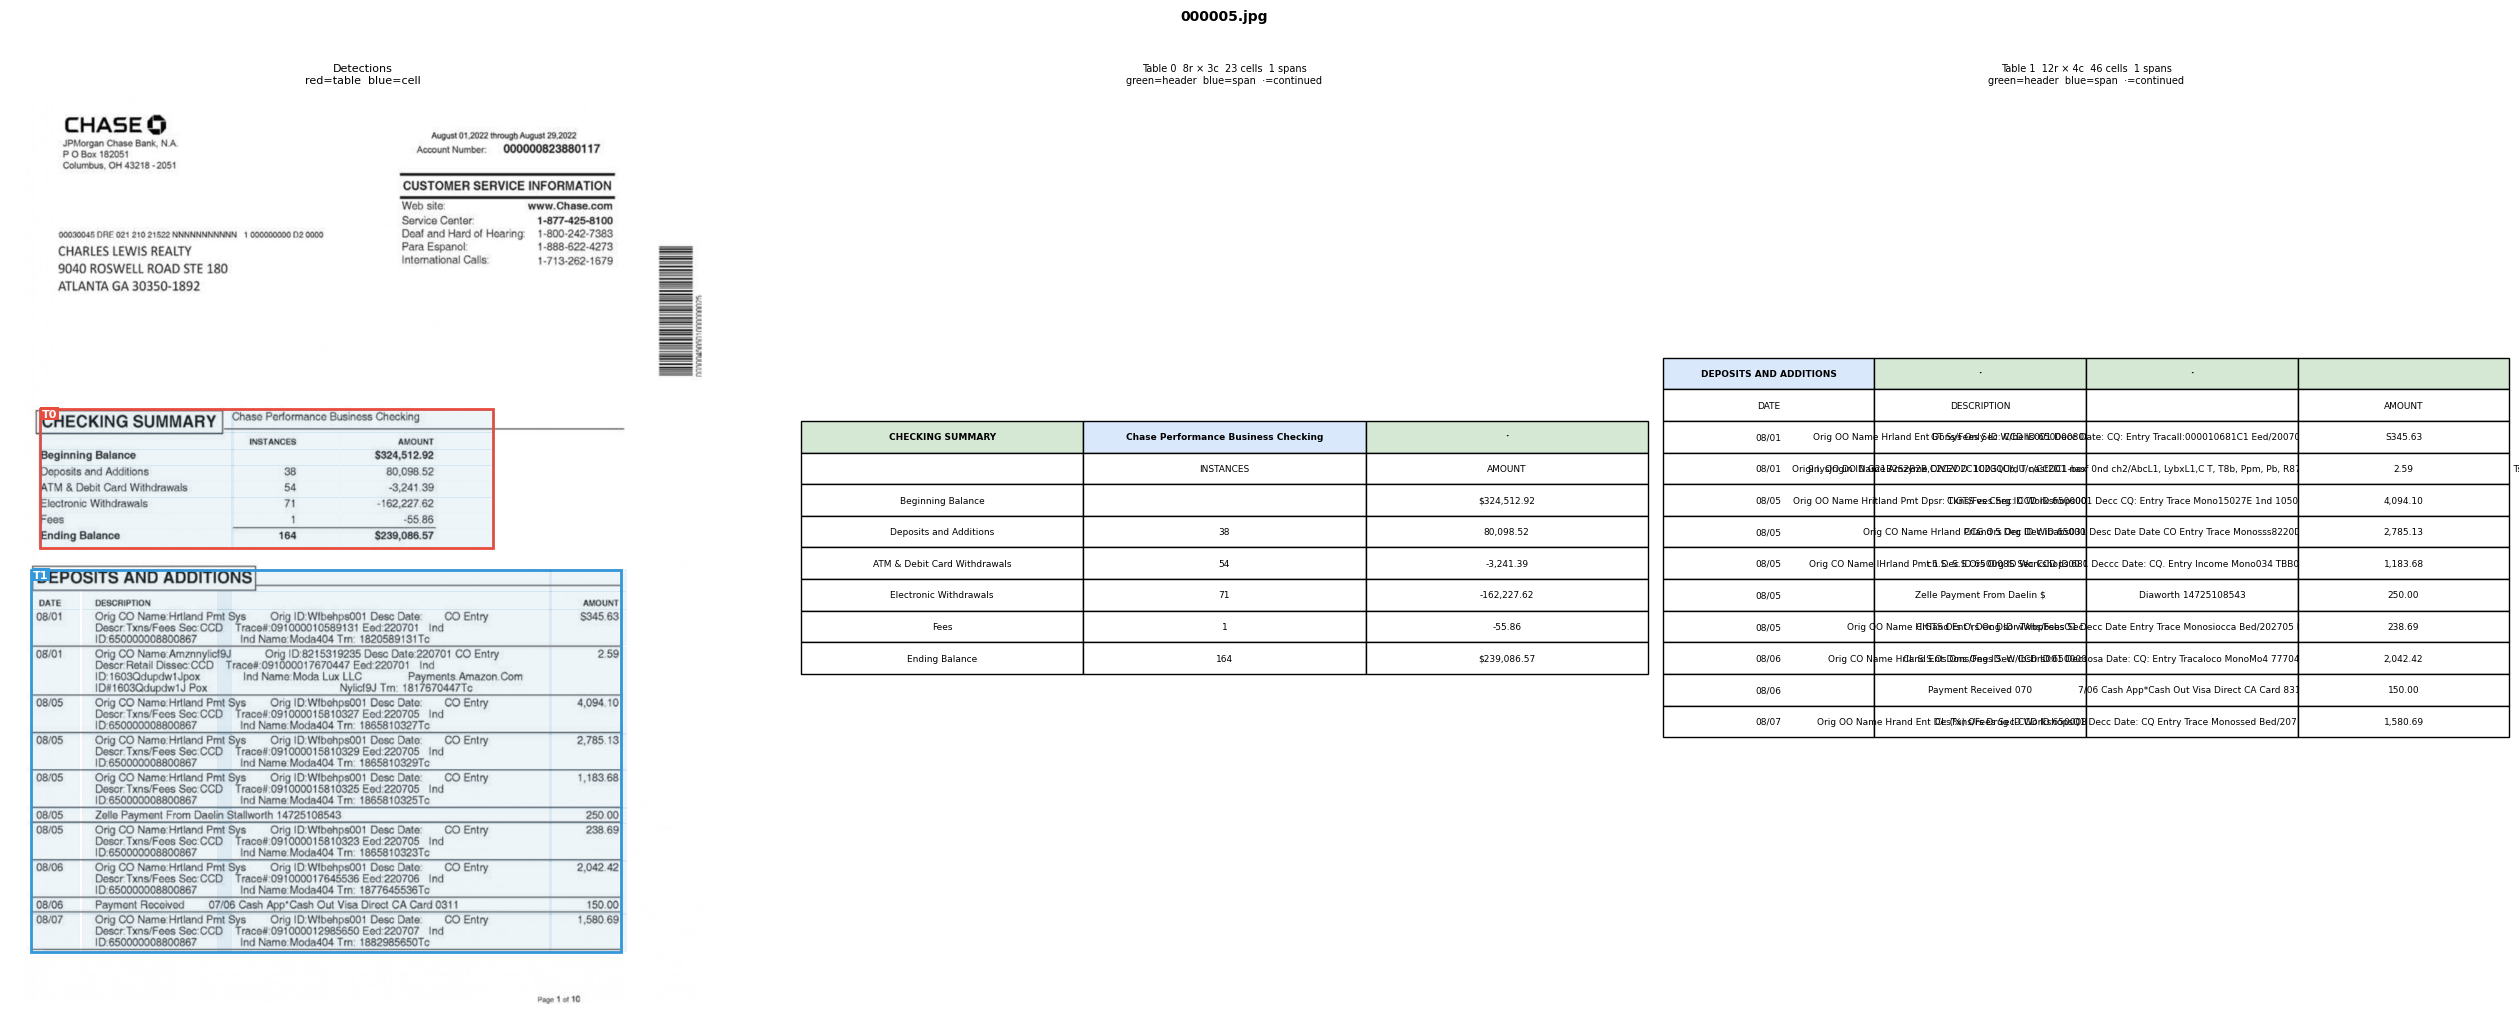

✅ 000005.jpg — 2 table(s)  saved → viz_000005.png


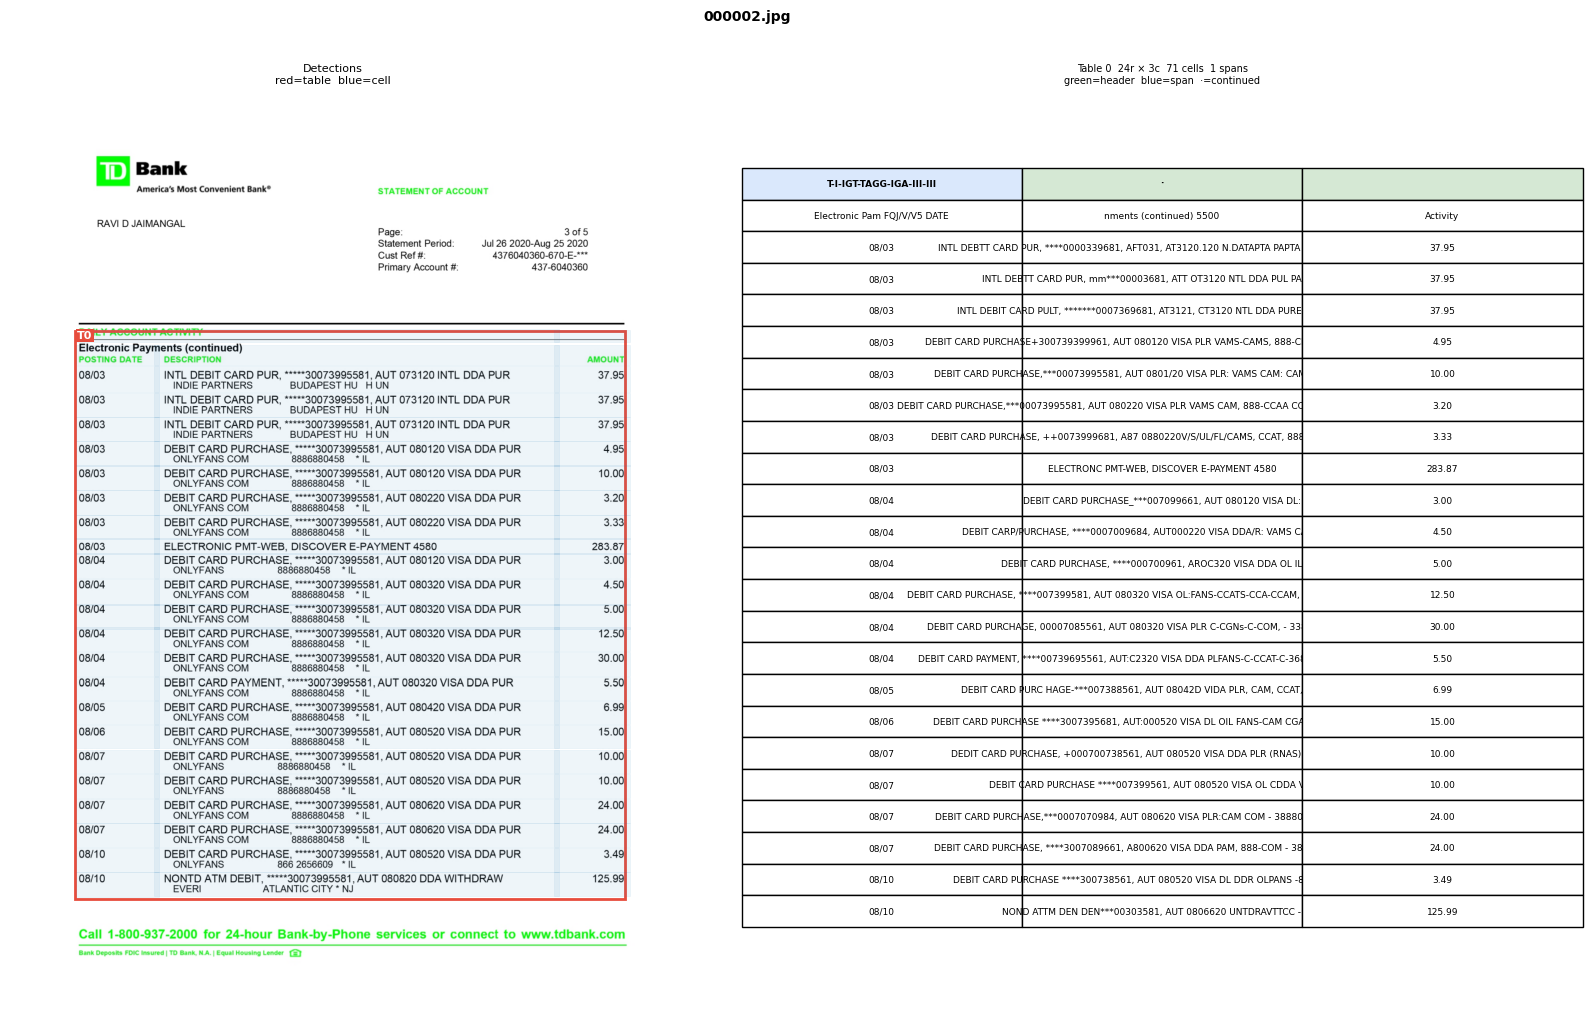

✅ 000002.jpg — 1 table(s)  saved → viz_000002.png


In [21]:

# VISUALIZATION — paste as new cell after Cell 6
import random, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

N_VIZ = 5  # number of images to visualize

# Pick random samples that have at least one table
has_tables = [r for r in submission if r['tables']]
samples    = random.sample(has_tables, min(N_VIZ, len(has_tables)))

for entry in samples:
    fname  = entry['filename']
    tables = entry['tables']

    # Find the image path
    img_path = next(
        (p for p in test_paths if os.path.basename(p) == fname), None)
    if img_path is None:
        print(f'⚠️  Image not found: {fname}'); continue

    page  = Image.open(img_path).convert('RGB')
    n_t   = len(tables)

    fig   = plt.figure(figsize=(8 + 9*n_t, 10))
    fig.suptitle(fname, fontsize=10, fontweight='bold', y=1.01)

    # ── Left panel: page with boxes ───────────────────────────
    ax_page = fig.add_subplot(1, 1+n_t, 1)
    ax_page.imshow(page); ax_page.axis('off')
    ax_page.set_title('Detections\nred=table  blue=cell', fontsize=8)

    COLORS = ['#E74C3C', '#3498DB', '#27AE60', '#9B59B6']
    for t in tables:
        col = COLORS[t['table_id'] % len(COLORS)]
        tx1,ty1,tx2,ty2 = t['bbox']
        ax_page.add_patch(mpatches.Rectangle(
            (tx1,ty1), tx2-tx1, ty2-ty1,
            lw=2, ec=col, fc='none'))
        ax_page.text(tx1+4, ty1+14, f'T{t["table_id"]}',
                     color='white', fontsize=8, fontweight='bold',
                     bbox=dict(fc=col, pad=1, lw=0))
        for c in t['cells']:
            bx1,by1,bx2,by2 = c['bbox']
            ax_page.add_patch(mpatches.Rectangle(
                (bx1,by1), bx2-bx1, by2-by1,
                lw=0.5, ec='#2980B9', fc='#2980B9', alpha=0.08))

    # ── Right panels: one grid per table ─────────────────────
    for t in tables:
        ax = fig.add_subplot(1, 1+n_t, 2+t['table_id'])
        ax.axis('off')
        cells = t['cells']
        if not cells:
            ax.set_title(f'Table {t["table_id"]} — no cells')
            continue

        n_rows = max(c['row'] + c['rowspan'] for c in cells)
        n_cols = max(c['col'] + c['colspan'] for c in cells)

        # Fill grid — spans show ↓→ markers
        grid = {}
        for c in cells:
            for dr in range(c['rowspan']):
                for dc in range(c['colspan']):
                    key = (c['row']+dr, c['col']+dc)
                    if key not in grid:
                        grid[key] = c['text'] if dr==0 and dc==0 else '·'

        data = [
            [grid.get((r, c), '') for c in range(n_cols)]
            for r in range(n_rows)
        ]

        tbl = ax.table(cellText=data, loc='center', cellLoc='center')
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(6.5)
        tbl.scale(1, 1.6)

        # Color: header row green, spanning cells blue
        for ci in range(n_cols):
            if (0, ci) in tbl._cells:
                tbl[(0, ci)].set_facecolor('#D5E8D4')
                tbl[(0, ci)].set_text_props(fontweight='bold')
        for c in cells:
            if c['rowspan'] > 1 or c['colspan'] > 1:
                if (c['row'], c['col']) in tbl._cells:
                    tbl[(c['row'], c['col'])].set_facecolor('#DAE8FC')

        n_spans = sum(1 for c in cells
                      if c['rowspan']>1 or c['colspan']>1)
        ax.set_title(
            f'Table {t["table_id"]}  '
            f'{n_rows}r × {n_cols}c  '
            f'{len(cells)} cells  {n_spans} spans\n'
            f'green=header  blue=span  ·=continued',
            fontsize=7)

    plt.tight_layout()
    out = f'viz_{os.path.splitext(fname)[0]}.png'
    plt.savefig(out, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'✅ {fname} — {n_t} table(s)  saved → {out}')
